# W02 Thursday · From new evidence to a defensible decision
## IIT414W · 10 September 2026 · 12:30–15:00

Last week you predicted which team would earn more **new points across Italy and Spain: Ferrari or McLaren**. Italy has now happened; Spain has not. Today you will preserve your first forecast, update it using observed evidence, then examine how data quality can change a decision.

**Route:** prediction update (20 min) → EDA demonstration (20 min) → studio with a 10-minute break (70 min) → peer review (25 min) → revision and save (15 min).

Work on your own copy. Discussion and documented AI assistance are allowed. This is formative work: no new graded submission. You do not need prior F1 knowledge. Lab 0 is already operational; this notebook does not add requirements to it.

**Two separate data contexts:** 2026 is a live forecasting *case frozen after Italy*. The EDA practice uses 2019–2021 development data. Neither the 2026 case nor 2023–2024 belongs in today's historical analysis. No model is trained here.

Run one cell at a time and pause at the prompts. A clean **Run All** also completes with personal responses left empty; successful execution does not mean you have answered the questions.

### 1 · Preserve the original call before discussing the update

Find your original card. Use one sign throughout: **gap = Ferrari points − McLaren points**.
- Ferrari by 12 means `+12`; McLaren by 9 means `-9`; a tie means `0`.
- Enter your original two-GP gap and confidence only if recorded. `None` means unknown, not zero.
- If you had only a winner, keep the numeric gap empty and record the winner in the note.
- Do not overwrite the original to match what you know now. If you already know Italy's result, this is a retrospective copy of your old card, not a fresh blind forecast.

In [1]:
original_total_gap = 32          # Copy your 3 Sep two-GP gap, Ferrari minus McLaren.
original_confidence_pct = 70     # Copy only if actually recorded.
original_note = "Ferrari's having an overall better season than McLaren, they are having an amazing season with a pretty dominant performance over McLaren and should continue to do so." # Original winner/reasons; or explain why the card is unavailable.
original_record = {
    "forecast_date": "2026-09-03", "total_gap_F_minus_M": original_total_gap,
    "confidence_pct": original_confidence_pct, "original_note": original_note,
}
print("Original record preserved separately. Empty fields remain unknown.")

Original record preserved separately. Empty fields remain unknown.


### 2 · Open the complete local package

Extract the ZIP first. Open this notebook from `unit_I/week_02/`. The supplied CSVs and helper are required. No API calls, FastF1 downloads or automatic package installations run in class. If imports fail, follow `W02_Thu_runbook_v1.md` or use the local reading guide and CSVs.

In [2]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

start = Path.cwd().resolve()
ROOT = next((p for p in [start, *start.parents] if (p / ".iit414w-root").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Extract the complete ZIP, including .iit414w-root, then reopen the notebook.")
sys.path.insert(0, str(ROOT / "unit_I/week_02"))
from w02_thu_support_v1 import (load_italy, verified_file, load_historical, merge_historical,
    feature_audit, summary_by, update_forecast, export_evidence)

RANDOM_SEED = 414
np.random.seed(RANDOM_SEED)
plt.rcParams.update({"figure.figsize": (9, 4.5), "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.facecolor": "white"})
FIGURES = {}
print("Local package found. Seed:", RANDOM_SEED)

Local package found. Seed: 414


### 3 · Reveal the observed result: Italy only

Team points add the points of both drivers, including zero-point finishes or retirements. A retirement is still part of the team outcome. Do not remove it from the denominator or replace it with hypothetical points.

The following four rows are an instructor-transcribed extract of the [official Italy 2026 result](https://www.formula1.com/en/results/2026/races/1293/italy/race-result). The manifest records the source and file hash. It is a local snapshot, not proof that your computer accessed F1 online.

,driver_name,constructor_id,classification,status,points
0,Lando Norris,mclaren,4,Finished,12
1,Oscar Piastri,mclaren,5,Finished,10
2,Lewis Hamilton,ferrari,6,Finished,8
3,Charles Leclerc,ferrari,NC,DNF,0


,Italy_points
constructor_id,
ferrari,8
mclaren,22


Observed Italy gap (Ferrari - McLaren): -14 points


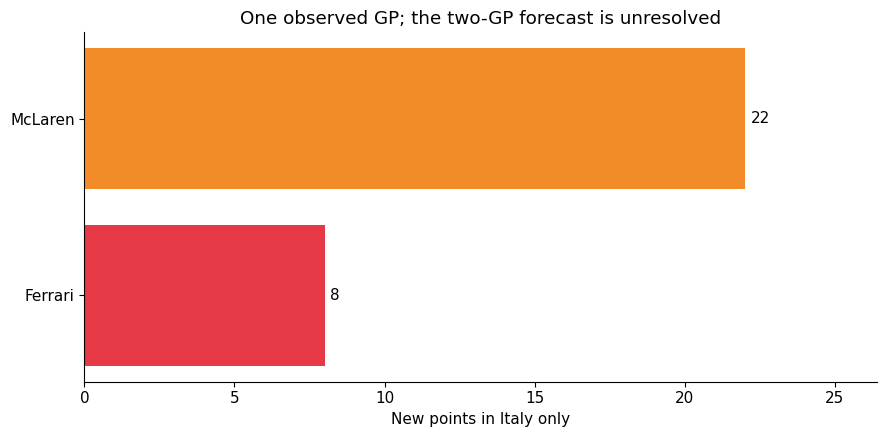

In [3]:
italy, team_points, observed_gap = load_italy(ROOT)
display(italy[["driver_name", "constructor_id", "classification", "status", "points"]])
display(team_points.rename("Italy_points").to_frame())
print(f"Observed Italy gap (Ferrari - McLaren): {observed_gap:+.0f} points")
fig, ax = plt.subplots()
values = [team_points["ferrari"], team_points["mclaren"]]
bars = ax.barh(["Ferrari", "McLaren"], values, color=["#E63946", "#F28C28"])
ax.bar_label(bars, padding=4, fmt="%.0f")
ax.set(xlabel="New points in Italy only", title="One observed GP; the two-GP forecast is unresolved", xlim=(0,max(values)*1.2))
fig.tight_layout(); FIGURES["italy_points"] = fig
plt.show()

### 4 · Update the same target, not a different question

Let `D_Italy` be the observed Ferrari-minus-McLaren gap and `D_Spain` the still-unknown gap. The final target remains:

**D_total = D_Italy + D_Spain = −14 + D_Spain.**

The instructor reports that nine of ten first calls favoured Ferrari, and one favoured McLaren by 9 points across both GPs. These are votes, not a 90% probability, and not ten independent experiments. No original individual confidence values are available in this packet.

Write privately before comparing answers:
1. What does Ferrari need in Spain to finish ahead over the full window? What would create a tie?

- Ferrari has to achieve a +14 points gap to finish ahead of McLaren, if they only get to +14 points gap they'll tie. 

2. What Spain gap would keep the original “McLaren by 9” forecast exactly right?

- Ferrari should get a +5 points gap to get the 'McLaren by 9' forecast exactly right. 

3. Which new fact changes your expectation, and which part is still an assumption?

- The fact that Ferrari has a -14 points gap with McLaren, just getting a tie with them is already difficult.

4. Does one retirement establish a team's future pace or retirement probability? What additional evidence would you request?

- 
Do not declare the minority forecast correct yet. A correct final sign would not, on its own, validate the reasoning or the nine-point magnitude.

In [4]:
# Arithmetic scenarios, NOT a predictive distribution and NOT equally likely outcomes.
scenarios = pd.DataFrame({"hypothetical_Spain_gap_F_minus_M": [-10, 0, 14, 20]})
scenarios["final_two_GP_gap_F_minus_M"] = observed_gap + scenarios["hypothetical_Spain_gap_F_minus_M"]
scenarios["two_GP_outcome"] = scenarios["final_two_GP_gap_F_minus_M"].map(
    lambda x: "Ferrari" if x > 0 else "McLaren" if x < 0 else "Tie")
display(scenarios)

,hypothetical_Spain_gap_F_minus_M,final_two_GP_gap_F_minus_M,two_GP_outcome
0,-10,-24.0,McLaren
1,0,-14.0,McLaren
2,14,0.0,Tie
3,20,6.0,Ferrari


### Your revision · 5 minutes

Enter your expected **Spain-only** gap. Optionally add a plausible lower/upper gap and three subjective probabilities for the **full Italy + Spain outcome**. A plausible range is not a calibrated confidence interval, and it does not determine those probabilities. You may retain your prediction if you explain why the evidence does not change it.

To compare the information available last week, the optional next cell shows the original shared chart data. Its weekend totals include Sprint points where flagged. That changes scoring opportunities: do not average Sprint and non-Sprint weekends as though they had identical scope. This reference is not a newly fitted prediction model.

In [5]:
# Optional reference: the exact evidence packet used for the first prediction.
p, _ = verified_file(ROOT, "w01_shared_evidence_2026_v1.json")
shared_evidence = pd.DataFrame(json.loads(p.read_text(encoding="utf-8"))["rows"])
display(shared_evidence[["event", "sprint", "ferrari", "mclaren"]])

,event,sprint,ferrari,mclaren
0,Australia,False,27,10
1,China,True,40,8
2,Japan,False,23,28
3,Miami,True,20,48
4,Canada,True,37,12
5,Monaco,False,18,10
6,Barcelona-Catalunya,False,25,25
7,Austria,False,14,18
8,Great Britain,True,51,20
9,Belgium,False,30,16


In [8]:
expected_spain_gap = -4       # Your new expectation, Ferrari minus McLaren.
spain_gap_low = -24            # Optional plausible lower bound.
spain_gap_high = 6           # Optional plausible upper bound.
full_horizon_probabilities = {"Ferrari": 5, "Tie": 5, "McLaren": 90}  # Optional: {"Ferrari": ..., "Tie": ..., "McLaren": ...}, total 100.
new_fact = "Mercedes's having an amazing season with 2 incredible drivers, Kimi Antonelli just pulled of an unbelieavable comeback from P19 to P1 so it's really hard for ferrari to get on the podium"                  # Refer to a row/source you actually inspected.
remaining_assumption = "There could always be a crash or mechanical failure, but I think Ferrari is still the better team and will finish over McLaren at the end of the season."  # Refer to a row/source you actually inspected.
why_change_or_keep = "The Italy GP was a disaster for Ferrari, they concided a lot of points to McLaren and it's hard to close the gap in one race."  # Refer to a row/source you actually inspected
next_data_request = "Analyze time differences between Ferrari, McLaren and the top contenders, Redbull and Mercedes, to evaluate the possibility of ending on the podium."  # Refer to a row/source you actually inspected
update = None
if expected_spain_gap is None:
    print("No personal update entered yet. This is an open response, not a zero prediction.")
else:
    update = update_forecast(observed_gap, expected_spain_gap, spain_gap_low, spain_gap_high,
                             full_horizon_probabilities)
    display(pd.Series(update, name="Your update"))
    if original_total_gap is not None:
        print(f"Change in two-GP expected gap: {update['expected_total_gap'] - original_total_gap:+.1f}")

observed_italy_gap                                                -14.0
expected_spain_gap                                                 -4.0
expected_total_gap                                                -18.0
total_gap_low                                                     -38.0
total_gap_high                                                     -8.0
subjective_probabilities_pct    {'Ferrari': 5, 'Tie': 5, 'McLaren': 90}
Name: Your update, dtype: object

Change in two-GP expected gap: -50.0


### 5 · From forecast revision to decision-oriented EDA

The update required you to separate observed evidence from an assumption. EDA follows the same discipline: **question → minimum data → check → analysis → interpretation → decision**.

**Practice question:** Before a race starts, how useful is qualifying position as a candidate signal for a top-10 race finish? This is an association question, not proof that changing qualifying position causes a different result.

**Glossary:** a season is a year; a round identifies a race within a year; a driver-race row is one driver's entry for one race. Qualifying establishes a session ranking. Q1/Q2/Q3 are successive qualifying segments, so many drivers have no Q3 time. The final starting grid can differ because of penalties or the weekend format. `position` is the race classification order; `position_text` and `status` add context and must be inspected separately.

Today use 2019–2021 only. The course's later model split remains train ≤2021, calibration 2022, test 2023–2024. This packet is not the full dataset for Lab 1.

In [9]:
MODE = "snapshot"  # Change explicitly to "synthetic" only for the fictional-data contingency.
qualifying, results, provenance = load_historical(ROOT, MODE)
print(provenance)
print(f"Qualifying rows: {len(qualifying):,}; result rows: {len(results):,}")
display(qualifying[["season", "round", "driver_id", "qualifying_position", "q1", "q2", "q3"]].head(6))
display(results.groupby("season").agg(driver_race_rows=("driver_id","size"),events=("round","nunique")))

PROVIDED_REAL_SNAPSHOT: Jolpica 2019-2021, no current API request
Qualifying rows: 1,197; result rows: 1,200


,season,round,driver_id,qualifying_position,q1,q2,q3
0,2019,1,hamilton,1,1:22.043,1:21.014,1:20.486
1,2019,1,bottas,2,1:22.367,1:21.193,1:20.598
2,2019,1,vettel,3,1:22.885,1:21.912,1:21.190
3,2019,1,max_verstappen,4,1:22.876,1:21.678,1:21.320
4,2019,1,leclerc,5,1:22.017,1:21.739,1:21.442
5,2019,1,grosjean,6,1:22.959,1:21.870,1:21.826


,driver_race_rows,events
season,,
2019,420,21
2020,340,17
2021,440,22


### Studio A · Audit before joining

Start by checking the unit of observation and coverage. Never join on a driver's name alone. The key is `(season, round, driver_id)`.

The results table defines our population. A left join keeps race-result entries without qualifying records; it does not silently remove them. In the coverage table, `left_only` means results without qualifying and `right_only` means qualifying without results. Neither is automatically a data error: investigate.

In [10]:
eda, join_coverage = merge_historical(qualifying, results)
display(join_coverage)
print("Rows before/after left join:", len(results), len(eda))
print("Grid=0 rows retained:", int(eda["grid"].eq(0).sum()))
print("Missing qualifying records retained:", int(eda["qualifying_position"].isna().sum()))
audit = feature_audit(eda)
display(audit[audit["field"].isin(["qualifying_position", "q1_seconds", "q2_seconds", "q3_seconds", "grid", "position", "status", "points"])])

,coverage,rows
0,both,1197
1,left_only,3
2,right_only,0


Rows before/after left join: 1200 1200
Grid=0 rows retained: 29
Missing qualifying records retained: 3


,field,dtype,missing_n,missing_pct,distinct_nonmissing
8,grid,int64,0,0.000000,21
9,position,int64,0,0.000000,20
11,status,string,0,0.000000,39
12,points,float64,0,0.000000,23
14,qualifying_position,float64,3,0.250000,20
18,q1_seconds,float64,20,1.666667,1160
19,q2_seconds,float64,313,26.083333,869
20,q3_seconds,float64,616,51.333333,577


### Your feature audit · about 15 minutes

Use the output to complete at least four entries below. Write whether the field is available **just before the race**, whether it is a candidate feature, an outcome or a diagnostic field, and why. Keep the prediction time fixed: a field available before the race may still be unavailable before qualifying.

Inspect `status` together with classification before making claims about retirements. Missing Q3 can reflect not reaching that segment or not recording a usable time; a missing cell alone does not establish the cause. Do not fill absent Q3 with zero or a universal mean. In 2021 Sprint weekends, qualifying rank and the eventual race grid can describe different competitive steps.

In [12]:
feature_decisions = pd.DataFrame({
    "field": ["qualifying_position", "q3_seconds", "grid", "position", "points", "status"],
    "available_at_prediction_time": ["Just after qualifying, before the race", "After Q3", "Just before the race", "Just after the race", "Just after the race", "Just after the race"],
    "role_and_reason": ["When qualifying ends, this variable shows where the driver's starting in case there's no penalties", "The lap time achieved during Q3, measured in real time in case there're no penalties", "The starting position for the race, after the FIA rules the penalties", "The finishing position of the race, after the FIA rules the penalties", "The points earned in the race, after the FIA rules the penalties", "The status of the driver at the end of the race, after the FIA rules the penalties"],
    "missing_value_decision": ["The driver did not participate in qualifiying or was disqualified", "The driver did not complete Q3 or didn't make it to Q3", "The driver was penalized and did not start the race or started from the pit lane", "The driver did not finish the race, either DNF or disqualified", "The driver did not finish in the top 10 or was DNF", "The driver was not eligible for the race, either due to a penalty or a technical issue"],
})
# Edit the lists above, or write an equivalent table in a Markdown cell.
display(feature_decisions)

,field,available_at_prediction_time,role_and_reason,missing_value_decision
0,qualifying_position,"Just after qualifying, before the race","When qualifying ends, this variable shows wher...",The driver did not participate in qualifiying ...
1,q3_seconds,After Q3,"The lap time achieved during Q3, measured in r...",The driver did not complete Q3 or didn't make ...
2,grid,Just before the race,"The starting position for the race, after the ...",The driver was penalized and did not start the...
3,position,Just after the race,"The finishing position of the race, after the ...","The driver did not finish the race, either DNF..."
4,points,Just after the race,"The points earned in the race, after the FIA r...",The driver did not finish in the top 10 or was...
5,status,Just after the race,The status of the driver at the end of the rac...,"The driver was not eligible for the race, eith..."


### Studio A · Who disappears when you keep only Q3?

The demonstration below checks missing Q3 by qualifying band, then compares the full result population with the subset that has Q3. Compare the denominators before interpreting either rate. The subset statistic describes the selected subset; the question is whether that is the population your decision concerns.

,qualifying_band,rows,missing_q3,missing_q3_pct
0,P1–P10,600,16,2.666667
1,P11–P15,300,300,100.000000
2,P16+,297,297,100.000000
3,No qualifying record,3,3,100.000000


,population,n,top10_rate_pct
0,All result entries,1200,50.000000
1,Only entries with Q3,584,75.171233


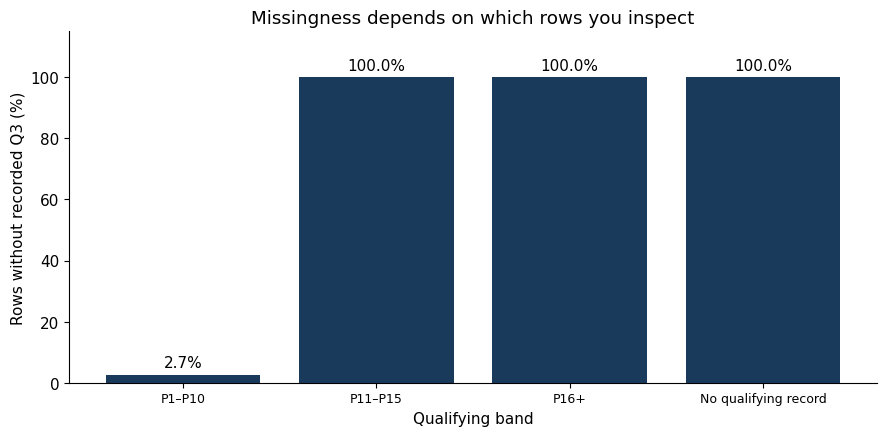

In [13]:
q3_coverage = eda.groupby("qualifying_band",observed=True,dropna=False).agg(
    rows=("driver_id","size"), missing_q3=("q3_seconds",lambda s:s.isna().sum())).reset_index()
q3_coverage["missing_q3_pct"] = 100*q3_coverage["missing_q3"]/q3_coverage["rows"]
display(q3_coverage)
selection_comparison = pd.DataFrame([
    {"population":"All result entries", "n":len(eda), "top10_rate_pct":100*eda["top10"].mean()},
    {"population":"Only entries with Q3", "n":int(eda["q3_seconds"].notna().sum()),
     "top10_rate_pct":100*eda.loc[eda["q3_seconds"].notna(),"top10"].mean()},
])
display(selection_comparison)
fig, ax = plt.subplots()
bars=ax.bar(q3_coverage["qualifying_band"],q3_coverage["missing_q3_pct"],color="#1A3A5C")
ax.bar_label(bars,labels=[f"{v:.1f}%" for v in q3_coverage["missing_q3_pct"]],padding=3)
ax.set(ylim=(0,115),ylabel="Rows without recorded Q3 (%)",xlabel="Qualifying band",
       title="Missingness depends on which rows you inspect")
ax.tick_params(axis="x",labelsize=9)
fig.tight_layout(); FIGURES["q3_coverage"] = fig
plt.show()

**Write before the break:** What population does each rate describe? Which result could mislead a decision about all drivers? State what you would keep, exclude or investigate and why. Leave your data-quality decision in the response cell near the end.

**Break · 10 minutes.** Save the notebook. No task during the break.

### Studio B · A graph must answer a question

The next demonstration estimates the observed top-10 finish rate by qualifying band. `n` counts driver-race rows, not independent races. Drivers share race conditions and appear repeatedly. These are descriptive associations from this sample, not causal effects or calibrated forecasts.

Keep `No qualifying record` visible if present. `top10` uses race classification order ≤10; `scored_points` uses observed points >0. They are separate definitions, even if their values often coincide.

,qualifying_band,driver_race_rows,top10_n,top10_rate_pct,scored_points_rate_pct
0,P1–P10,600,445,74.166667,74.166667
1,P11–P15,300,120,40.000000,40.000000
2,P16+,297,34,11.447811,11.447811
3,No qualifying record,3,1,33.333333,33.333333


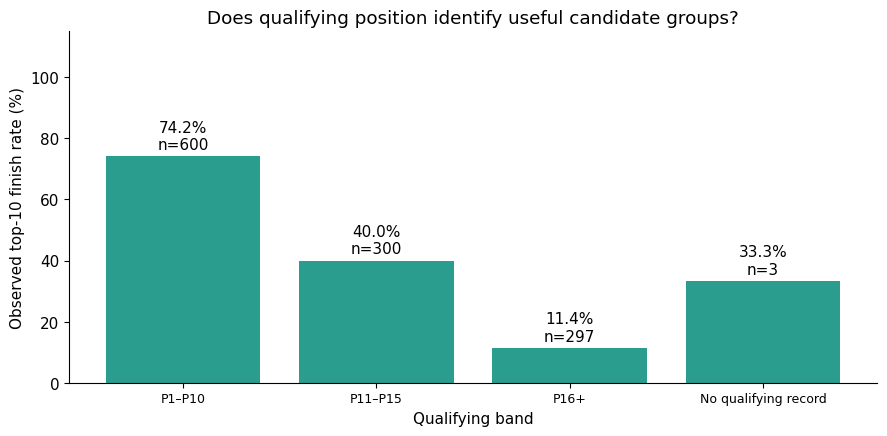

In [14]:
band_summary = summary_by(eda, "qualifying_band")
display(band_summary)
fig,ax=plt.subplots()
bars=ax.bar(band_summary["qualifying_band"],band_summary["top10_rate_pct"],color="#2A9D8F")
ax.bar_label(bars,labels=[f"{p:.1f}%\nn={n}" for p,n in zip(band_summary["top10_rate_pct"],band_summary["driver_race_rows"])],padding=3)
ax.set(ylim=(0,115),ylabel="Observed top-10 finish rate (%)",xlabel="Qualifying band",
       title="Does qualifying position identify useful candidate groups?")
ax.tick_params(axis="x",labelsize=9)
fig.tight_layout(); FIGURES["top10_by_band"] = fig
plt.show()

### Your analysis · choose a useful comparison

Use this scaffold to test whether the pooled finding changes by season. You can restrict the circuit with `CIRCUIT_ID`, or compare the whole dataset. Ask a question first and justify the scope. To see available circuits, run `sorted(eda.circuit_id.unique())`.

You may change the code. Do not substitute a graph for its interpretation. If a slice is empty or very small, report that limitation instead of inventing a result. Historical patterns from 2019–2021 are not a direct prediction of a new 2026 Madrid event.

In [ ]:
CIRCUIT_ID = None   # For example "monza" with real snapshots. None keeps all circuits.
analysis_question = ""   # Your question, before inspecting the comparison.
scope_reason = ""
focus = eda if CIRCUIT_ID is None else eda.loc[eda["circuit_id"].eq(CIRCUIT_ID)].copy()
season_summary = pd.DataFrame()
if focus.empty:
    print("Empty slice. Check the circuit identifier; no graph or claim has been produced.")
else:
    season_summary = summary_by(focus,["season","qualifying_band"])
    display(season_summary)
    fig,ax=plt.subplots()
    for band,g in season_summary.groupby("qualifying_band",observed=True):
        if band == "No qualifying record":
            print("No qualifying record remains in the table; too few rows for a useful trend line:", int(g["driver_race_rows"].sum()))
            continue
        ax.plot(g["season"],g["top10_rate_pct"],marker="o",label=str(band))
    ax.set(ylim=(0,105),xticks=sorted(focus["season"].unique()),xlabel="Season",
           ylabel="Observed top-10 finish rate (%)",title=f"Check temporal variation · {CIRCUIT_ID or 'all circuits'}")
    ax.legend(fontsize=9,loc="best")
    fig.tight_layout(); FIGURES["student_season_comparison"] = fig
    plt.show()

### 6 · Three insights, two questions, one decision · peer review

Each insight must refer to a displayed number, denominator, table or graph. Ask your partner to challenge one inference. Revise the decision or explain why you retain it. A well-supported negative finding is valid.

Keep one unresolved issue for Friday's work on spurious correlation, survivorship bias and anchoring. Do not add a new overnight task.

In [1]:
data_quality_decision = ("Keep all 1,200 result entries for the population analysis and keep the three rows without a qualifying record visible. "
                         "Do not replace missing Q3 with zero or a mean: Q3 is missing for 616/1,200 rows (51.3%), "
                         "including every P11-P15 and P16+ row, so restricting analysis to Q3 would select mostly the top qualifying group.")
insights = [
    "The left join preserved 1,200/1,200 result rows: 1,197 matched qualifying records and 3 were left_only; no qualifying-only rows remained.",
    "Top-10 finish rates differed by qualifying band: P1-P10 was 445/600 = 74.2%, P11-P15 was 120/300 = 40.0%, and P16+ was 34/297 = 11.4%.",
    "The Q3-only comparison was 439/584 = 75.2% versus 600/1,200 = 50.0% for all result entries, so the Q3-only rate is a selected-subset result rather than a population-wide estimate."
]
open_questions = [
    "How much of the qualifying-band association remains after accounting for circuit, season, team strength, grid penalties and Sprint-weekend format?",
    "Are the three rows without qualifying records and the 29 grid=0 rows handled consistently in a future prediction dataset, and what do their status/classification fields show?"
]
decision_before_feedback = ("Use qualifying position as a candidate feature and keep the full result population in the descriptive analysis, "
                            "but do not treat the band rates as causal effects or calibrated probabilities.")
partner_challenge = ("My partner challenged whether the 75.2% Q3-only rate could be generalized to all drivers and pointed out that "
                     "missing Q3 is concentrated outside P1-P10; I also checked the denominators and the selection table.")
decision_after_feedback = ("Retain qualifying position as a useful screening signal, but report the all-row band comparison and missingness audit together. "
                           "Do not use Q3 alone as a complete feature for every driver-race row without an explicit missingness strategy.")
why_revised_or_retained = ("I retained the decision because the association is large in this sample, but narrowed the claim after the selection check: "
                           "the evidence supports candidate-group identification, not a causal claim or a universal forecast. The P1-P10 and P16+ groups "
                           "have 600 and 297 rows, while the no-qualifying-record group has only 3 rows and should not drive interpretation.")
ai_use_and_verification = ("AI helped draft and organize these reflections from the notebook context. I verified the numerical claims against the displayed "
                           "join_coverage, q3_coverage, selection_comparison and band_summary outputs, including the denominators before writing the conclusions.")

### 7 · Save evidence, then save your notebook

The export keeps the original forecast and the update separate. Blank responses stay blank. Each run creates a new output folder; it does not overwrite the previous one. Save the notebook too: editing its Markdown is not automatically captured in the JSON export.

**Before leaving:** point to your source, one quality decision and one output you can explain. This is not an exit-ticket assignment or a grade. The weekly exit ticket is on Friday.

In [ ]:
personal = {
    "original": original_record, "updated": update,
    "new_fact": new_fact, "remaining_assumption": remaining_assumption,
    "why_change_or_keep": why_change_or_keep, "next_data_request": next_data_request,
    "analysis_question": analysis_question, "scope_reason": scope_reason,
    "data_quality_decision": data_quality_decision, "insights": insights,
    "open_questions": open_questions, "decision_before_feedback": decision_before_feedback,
    "partner_challenge": partner_challenge, "decision_after_feedback": decision_after_feedback,
    "why_revised_or_retained": why_revised_or_retained,
    "ai_use_and_verification": ai_use_and_verification,
}
out = export_evidence(ROOT, {
    "feature_audit": audit, "feature_decisions": feature_decisions,
    "join_coverage": join_coverage, "q3_coverage": q3_coverage,
    "selection_comparison": selection_comparison, "band_summary": band_summary,
    "season_summary": season_summary, "arithmetic_scenarios": scenarios,
}, personal, provenance, FIGURES)
print("Saved:", out.relative_to(ROOT))
print("Now save the notebook with your responses and outputs.")

### Continue on Friday

Bring this notebook and your unresolved question on Friday 11 September, 11:10–13:40. We will examine misleading conclusions and prepare the next lab. No classes run on 14–20 September. Lab 1 is due Thursday 24 September at 12:30; follow its current brief, not the old March instructions.

**Sources and limits**
- Historical data: [Jolpica endpoint documentation](https://github.com/jolpica/jolpica-f1/blob/main/docs/README.md); URLs and capture receipts in the local manifest. Qualifying and results are all available 2019–2021 records returned by the paginated queries, not a claim that every race entry has a qualifying record.
- Forecast update: [official Italy 2026 result](https://www.formula1.com/en/results/2026/races/1293/italy/race-result), cross-checked with [McLaren's race report](https://www.mclaren.com/racing/formula-1/2026/italian-grand-prix/race-report/); [Spain schedule](https://www.formula1.com/en/racing/2026/spain). Spain is unresolved in this frozen packet.
- Initial class aggregate: instructor report, 9 Ferrari / 1 McLaren; the numerical margin confirmed for McLaren is 9. Individual confidences and the other margins are not supplied.
- The W01 evidence JSON is the original shared packet, not a new empirical validation. The historical EDA data, the original 2026 reference and the Italy observation have distinct scopes.